# Análise de Obrigações

## Modelagem de tópicos para seleção de temas de risco

In [7]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils_ccd import get_connection, get_info_file_path, get_informacoes_processo, extract_text_from_pdf

conn_bddip = get_connection(db="BdDIP")
conn = get_connection()

from langchain_openai import  AzureChatOpenAI
from langchain.prompts import PromptTemplate

from dotenv import load_dotenv
load_dotenv("../.env")

True

In [8]:
sql_obrigacoes = """
SELECT [IdObrigacao]
      ,o.[IdProcesso]
      ,[IdComposicaoPauta]
      ,[IdVotoPauta]
      ,[DescricaoObrigacao]
      ,[DeFazer]
      ,[Prazo]
      ,[DataCumprimento]
      ,[OrgaoResponsavel]
      ,[IdOrgaoResponsavel]
      ,[TemMultaCominatoria]
      ,[NomeResponsavelMultaCominatoria]
      ,[DocumentoResponsavelMultaCominatoria]
      ,[IdPessoaMultaCominatoria]
      ,[ValorMultaCominatoria]
      ,[PeriodoMultaCominatoria]
      ,[EMultaCominatoriaSolidaria]
      ,[SolidariosMultaCominatoria]
      ,[Cancelado]
  FROM [BdDIP].[dbo].[Obrigacao] o 
  INNER JOIN [processo].[dbo].[Processos] p ON o.IdProcesso = p.IdProcesso
  WHERE p.codigo_tipo_processo NOT IN ('APO')
  AND DataCumprimento IS NOT NULL

"""
df_obrigacoes = pd.read_sql(sql_obrigacoes, conn_bddip)

In [9]:
df_obrigacoes 

,IdObrigacao,IdProcesso,IdComposicaoPauta,IdVotoPauta,DescricaoObrigacao,DeFazer,Prazo,DataCumprimento,OrgaoResponsavel,IdOrgaoResponsavel,TemMultaCominatoria,NomeResponsavelMultaCominatoria,DocumentoResponsavelMultaCominatoria,IdPessoaMultaCominatoria,ValorMultaCominatoria,PeriodoMultaCominatoria,EMultaCominatoriaSolidaria,SolidariosMultaCominatoria,Cancelado
0,2,564793,107122,33493,Atualizar as informações necessárias ao SIAI-a...,True,15 dias úteis,2023-02-14,Consórcio Intermunicipal Multifinalitário Poti...,1294.0,True,Fernando Luiz Teixeira de Carvalho,47611278487,21905.0,NaN,diário,False,null,None
1,3,564793,107122,33493,Atualizar as informações necessárias ao SIAI-a...,True,15 dias úteis,2023-02-14,CONSÓRCIO INTERMUNICIPAL MULTIFINALITARIO POTI...,1294.0,True,Fernando Luiz Teixeira de Carvalho,47611278487,21905.0,NaN,diário,False,null,None
2,6,512738,113124,38047,"Providenciar, no prazo de 30 (trinta) dias úte...",True,30 dias úteis,2024-03-04,PREFEITURA MUNICIPAL DE BOM JESUS,351.0,True,CLÉCIO DA CÂMARA AZEVEDO,30806062487,3771.0,100.0,diário,False,null,None
3,12,505850,113161,38048,"assinatura do prazo de 18 (dezoito) meses, a c...",True,18 meses,2025-07-25,PREFEITURA MUNICIPAL DE SAO BENTO DO NORTE,455.0,True,João Maria Montenegro da Silva,48148750459,9734.0,1000.0,diário,True,"[""Jo\u00e3o Maria Montenegro da Silva""]",None
4,13,505850,113161,38048,Apresentar um plano para enfrentamento e elimi...,True,60 dias,2024-03-26,PREFEITURA MUNICIPAL DE SAO BENTO DO NORTE,455.0,True,João Maria Montenegro da Silva,48148750459,9734.0,1000.0,diário,True,"[""Jo\u00e3o Maria Montenegro da Silva""]",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,1980,601396,123190,45924,Apresentar um plano de ação visando à amortiza...,True,60 dias úteis,2026-01-12,INSTITUTO DE PREVIDÊNCIA DOS SERVIDORES MUNICI...,1209.0,True,Manoel Francisco da Silva Carvalho,56645287453,1417.0,1000.0,diário,True,"[""INSTITUTO DE PREVID\u00caNCIA DOS SERVIDORES...",None
282,2018,594996,123825,46427,Determinar à Prefeitura Municipal de São José ...,True,30 dias úteis após o trânsito em julgado,2026-02-05,PREFEITURA MUNICIPAL DE SÃO JOSÉ DE MIPIBÚ,467.0,True,JOSÉ DE FIGUEREDO VARELA,09460098487,13044.0,200.0,diário,True,"[""Jucielly da Costa Freitas (CPF: 01019995424)...",None
283,2058,550929,102611,30673,Apresentar nova minuta de edital contendo as c...,True,90 dias,2023-02-08,COMPANHIA DE SERVIÇOS URBANOS DE NATAL,554.0,True,Joseildes Medeiros da Silva (Diretor Presidente),22127909453,61280.0,5000.0,diário,False,null,None
284,2060,560871,106783,33579,Determinar que o Prefeito Municipal de Santa M...,True,180 dias,2023-01-25,PREFEITURA MUNICIPAL DE SANTA MARIA,470.0,True,Raniery Soares Câmara,87451310400,14480.0,500.0,diário,False,null,None


In [10]:
df_obrigacoes.DescricaoObrigacao

0      Atualizar as informações necessárias ao SIAI-a...
1      Atualizar as informações necessárias ao SIAI-a...
2      Providenciar, no prazo de 30 (trinta) dias úte...
3      assinatura do prazo de 18 (dezoito) meses, a c...
4      Apresentar um plano para enfrentamento e elimi...
                             ...                        
281    Apresentar um plano de ação visando à amortiza...
282    Determinar à Prefeitura Municipal de São José ...
283    Apresentar nova minuta de edital contendo as c...
284    Determinar que o Prefeito Municipal de Santa M...
285    Fixar prazo de 180 (cento e oitenta) dias corr...
Name: DescricaoObrigacao, Length: 286, dtype: object

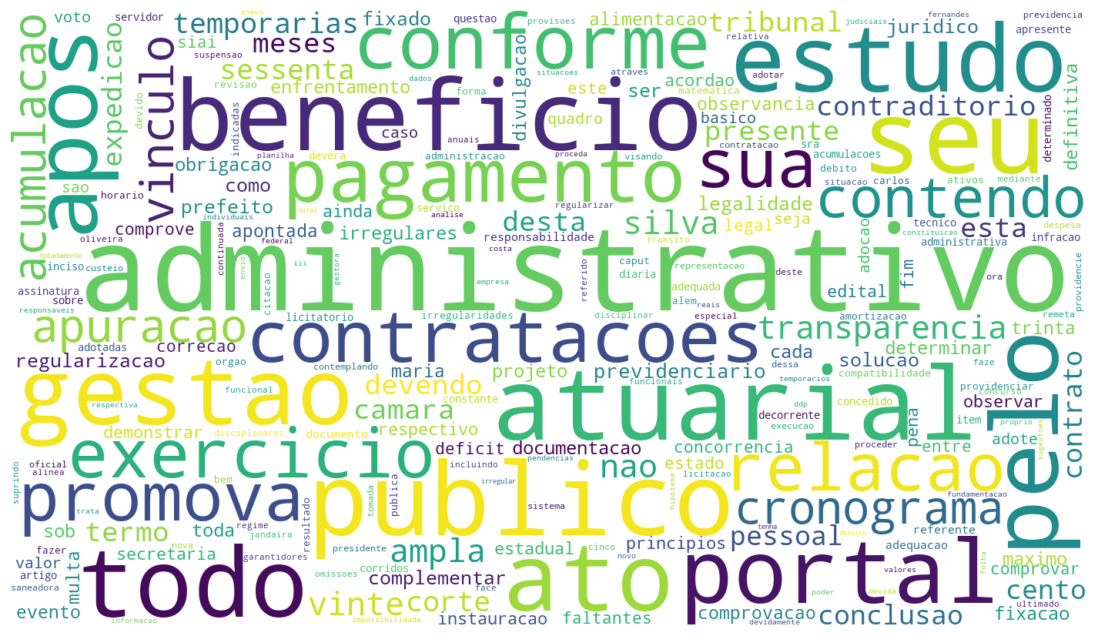

Mais comuns (menor IDF): ['30', '60', '90', 'acao', 'ao', 'aos', 'apresentacao', 'apresentar', 'art', 'ate', 'atual', 'autos', 'cargos', 'com', 'contar', 'contas', 'cumprimento', 'da', 'das', 'decisao', 'defesa', 'determinacao', 'deve', 'dias', 'dos', 'eliminacao', 'em', 'gestor', 'informacoes', 'intimacao'] ...


In [13]:
# pip install wordcloud scikit-learn unidecode matplotlib

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from unidecode import unidecode

# 1) Corpus
texts = (
    df_obrigacoes["DescricaoObrigacao"]
    .fillna("")
    .astype(str)
    .tolist()
)

def normalize_pt(s: str) -> str:
    s = unidecode(s.lower())
    s = re.sub(r"[^a-z0-9\s]", " ", s)      # tira pontuação
    s = re.sub(r"\s+", " ", s).strip()
    return s

texts_norm = [normalize_pt(t) for t in texts]

# 2) TF-IDF para descobrir palavras "mais comuns" (menor IDF = aparece em muitos docs)
#    Ajuste min_df/max_df conforme seu dataset.
vec = TfidfVectorizer(
    stop_words="english",   # opcional: troque por lista pt se tiver; vamos construir stopwords por idf abaixo
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)
X = vec.fit_transform(texts_norm)
terms = np.array(vec.get_feature_names_out())
idf = vec.idf_

# Palavras mais comuns = menor IDF
N_COMMON = 60  # <-- ajuste
common_terms = set(terms[np.argsort(idf)[:N_COMMON]])

# + stopwords pt básicas (opcional, mas ajuda)
stop_pt_basic = {
    "a","o","os","as","de","do","da","dos","das","e","em","no","na","nos","nas",
    "por","para","com","sem","que","se","ao","aos","à","às","um","uma","uns","umas",
    "art","arts","lei","decreto","portaria","resolucao","processo","autos"
}
stopwords_final = common_terms | stop_pt_basic

# 3) Texto final filtrado e WordCloud
def filter_text(s: str, stopset: set[str]) -> str:
    toks = s.split()
    toks = [t for t in toks if t not in stopset and len(t) >= 3 and not t.isdigit()]
    return " ".join(toks)

filtered_corpus = " ".join(filter_text(t, stopwords_final) for t in texts_norm)

wc = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    collocations=False,   # evita juntar bigramas comuns tipo "tribunal contas"
    max_words=250
).generate(filtered_corpus)

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

# (opcional) ver quais termos foram removidos por serem "muito comuns"
print("Mais comuns (menor IDF):", list(sorted(common_terms))[:30], "...")

In [14]:
# pip install scikit-learn unidecode nltk

import re
import numpy as np
import pandas as pd
from unidecode import unidecode

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# -----------------------------
# 1) Preparação do corpus
# -----------------------------

texts = (
    df_obrigacoes["DescricaoObrigacao"]
    .fillna("")
    .astype(str)
    .tolist()
)

def normalize_text(s: str) -> str:
    s = unidecode(s.lower())
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

texts_norm = [normalize_text(t) for t in texts]

# Stopwords jurídicas customizadas (ajuste conforme necessário)
stopwords_juridico = [
    "art", "arts", "lei", "decreto", "resolucao",
    "processo", "autos", "acordao", "tribunal",
    "contas", "estado", "municipio",
    "fica", "determina", "dever", "obrigacao"
]

In [15]:
vectorizer = TfidfVectorizer(
    max_df=0.90,
    min_df=5,
    stop_words=stopwords_juridico,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(texts_norm)

In [28]:
n_topics = 12

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",12
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [29]:
feature_names = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTópico {idx}:")
        print(" | ".join([feature_names[i] 
                           for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_topics(lda, feature_names)


Tópico 0:
do | pessoal | especial | de pessoal | todas as | todas | quadro | quadro de | voto | os cargos

Tópico 1:
do | no | da | que | em | rn | ao | dos | para | as

Tópico 2:
do | publico | do gestor | gestao | meio | por meio | por | de gestao | exercicio | exercicio de

Tópico 3:
acao | de acao | plano de | plano | um | atuarial | beneficios | um plano | amortizacao | visando

Tópico 4:
regularizar | situacao | 2024 | nos | cumprimento das | de jandaira | jandaira | itens | valores | ad

Tópico 5:
temporarios | de todos | contratos | contratos temporarios | os contratos | todos | todos os | irregularidade | da irregularidade | saneamento da

Tópico 6:
envio das | envio | projeto | providenciar | providenciar envio | devidas | das | bimestre | relativas | basico

Tópico 7:
sob | sob pena | pena | pena de | multa | de multa | fazer | diaria | pagamento | multa diaria

Tópico 8:
90 noventa | noventa dias | noventa | 90 | de 90 | transparencia | das informacoes | camara municipal |

In [30]:
topic_distribution = lda.transform(X)

df_obrigacoes["topic_id"] = topic_distribution.argmax(axis=1)

# Probabilidade do tópico dominante
df_obrigacoes["topic_score"] = topic_distribution.max(axis=1)

In [31]:
df_obrigacoes["topic_id"].value_counts().sort_index()

topic_id
0      15
1     115
2      16
3      11
4       6
5      11
6       9
7       7
8      20
9      39
10     11
11     26
Name: count, dtype: int64

In [32]:
topic_labels = {
    0: "Quadro de Pessoal e Cargos",
    1: "Conteúdo Genérico / Baixa Coerência Temática",
    2: "Gestão e Responsabilidade do Gestor",
    3: "Plano de Ação Atuarial e Amortização",
    4: "Regularização de Situação Administrativa (2024 / Município Específico)",
    5: "Saneamento de Contratações Temporárias",
    6: "Envio de Projeto ou Informações Periódicas",
    7: "Multa Diária por Descumprimento",
    8: "Transparência e Prazo de 90 Dias",
    9: "Plano de Solução com Prazo Máximo",
    10: "Prazo de 18 Meses para Saneamento",
    11: "Processos Administrativos e Apuração de Legalidade"
}

df_obrigacoes["grupo_descricao"] = df_obrigacoes["topic_id"].map(topic_labels)

In [ ]:
df_obrigacoes[df_obrigacoes["topic_id"].isin([5, 8])]['DescricaoObrigacao'].tolist()

31

In [38]:
for orgao, count in df_obrigacoes.OrgaoResponsavel.value_counts().items():
    print(f"{orgao}: {count} obrigações")

PREFEITURA MUNICIPAL DE JANDAÍRA: 10 obrigações
PREFEITURA MUNICIPAL DE SÃO GONÇALO DO AMARANTE: 10 obrigações
INSTITUTO DE PREVIDÊNCIA DOS SERVIDORES DO RN: 8 obrigações
PREFEITURA MUNICIPAL DE PENDÊNCIAS: 7 obrigações
PREFEITURA MUNICIPAL DE GOV DIX SEPT ROSADO: 7 obrigações
PREFEITURA MUNICIPAL DE ARÊS: 7 obrigações
Desconhecido: 6 obrigações
SECRETARIA DE ESTADO DA SAÚDE PUBLICA: 6 obrigações
PREFEITURA MUNICIPAL DE LAGOA NOVA: 6 obrigações
INSTITUTO DE PREVIDÊNCIA DOS SERVIDORES MUNICIPAIS DE SÃO TOMÉ: 6 obrigações
PREFEITURA MUNICIPAL DE ALEXANDRIA: 5 obrigações
SECRETARIA DE ESTADO DA INFRA-ESTRUTURA: 5 obrigações
PREFEITURA MUNICIPAL DE SERRA CAIADA: 5 obrigações
PREFEITURA MUNICIPAL DE VILA FLOR: 4 obrigações
PREFEITURA MUNICIPAL DE BOM JESUS: 4 obrigações
PREFEITURA MUNICIPAL DE NÍSIA FLORESTA: 4 obrigações
CONSÓRCIO PÚBLICO REGIONAL DE SANEAMENTO BÁSICO DO VALE DO ASSU DO RIO GRANDE DO NORTE: 4 obrigações
FUNDO DE SEGURIDADE SOCIAL DOS SERVIDORES PÚBLICOS DE MACAU: 4 obrigaç

In [39]:
df_obrigacoes[df_obrigacoes["topic_id"].isin([4])].DescricaoObrigacao.tolist()

['Apresentar documentação comprobatória do cumprimento das determinações previstas nos itens “a.1” e “a.2”',
 'Regularizar a falha apontada conforme estipulado.',
 'Regularizar a situação noticiada nos autos.',
 'Regularizar a situação noticiada nos autos.',
 'Colacionar documentalmente se, no todo ou em parte, decisões precárias relacionadas ao pagamento de honorários advocatícios ad exitum foram ou não supervenientemente revertidas e, nesta hipótese, informar se o contratado foi proporcionalmente onerado pela devolução dos valores recebidos pelo Município de Jandaíra/RN.',
 'Notificação do atual prefeito de Jandaíra para que informe, no prazo de 30 dias, itens relativos à quitação de honorários advocatícios ad exitum do escritório Paraguay Ribeiro Coutinho Advogados Associados, conforme detalhado no acórdão.']

In [41]:
df_obrigacoes[df_obrigacoes["DescricaoObrigacao"].str.contains("contas anuais", case=False, na=False)].DescricaoObrigacao.tolist()

['Entregar, por meio do portal do gestor, as Contas Anuais de Gestão do exercício de 2022',
 'Entregar, por meio do portal do gestor, as contas anuais de gestão do exercício de 2019',
 'Entregar, por meio do portal do gestor, as Contas Anuais de Gestão do exercício de 2021',
 'Expedir determinação de obrigação de fazer, assinando o prazo de 40 (quarenta) dias corridos para que o atual gestor do CONSÓRCIO PÚBLICO REGIONAL DE SANEAMENTO BÁSICO DO VALE DO ASSÚ, entregue, por meio do portal do gestor, as contas anuais de gestão do exercício de 2019.',
 'Expedir determinação de obrigação de fazer, assinando o prazo de 40 (quarenta) dias corridos para que o atual Prefeito do Município de Jandaira, entregue, por meio do portal do gestor, as contas anuais de gestão do exercício de 2016',
 'Em caso de impossibilidade de apresentação das contas, o atual Prefeito Municipal de Jandaira/RN deve comprovar justo impedimento, demonstrando que tomou todas as medidas determinadas no art. 22, parágrafo ú

# Repetidas

In [27]:
df_obrigacoes[(df_obrigacoes['IdProcesso'] == 73410) & (df_obrigacoes['IdComposicaoPauta'] == 115301) & (df_obrigacoes['IdVotoPauta'] == 39671)]

,IdObrigacao,IdProcesso,IdComposicaoPauta,IdVotoPauta,DescricaoObrigacao,DeFazer,Prazo,DataCumprimento,OrgaoResponsavel,IdOrgaoResponsavel,...,NomeResponsavelMultaCominatoria,DocumentoResponsavelMultaCominatoria,IdPessoaMultaCominatoria,ValorMultaCominatoria,PeriodoMultaCominatoria,EMultaCominatoriaSolidaria,SolidariosMultaCominatoria,Cancelado,Numero_Processo,Ano_Processo
4,490,73410,115301,39671,NOTIFICAÇÃO do Instituto de Previdência dos Se...,True,60 dias,2024-07-15,INSTITUTO DE PREVIDÊNCIA DOS SERVIDORES DO EST...,536.0,...,None,None,NaN,NaN,None,False,null,None,005194,2000


In [28]:
repetidos = df_obrigacoes.groupby(['IdProcesso', 'IdComposicaoPauta', 'IdVotoPauta', 'DescricaoObrigacao']).size().reset_index(name='counts')

In [29]:
repetidos

,IdProcesso,IdComposicaoPauta,IdVotoPauta,DescricaoObrigacao,counts
0,19456,117592,42069,"Após o trânsito em julgado deste decisum, reme...",1
1,40404,107805,34682,NOTIFICAÇÃO do Instituto de Previdência respon...,1
2,45183,117629,42117,"Com a publicação desta Decisão, o processo dev...",1
3,50964,116424,40909,"a Secretaria de Estado da Agricultura, da Pecu...",1
4,73410,115301,39671,NOTIFICAÇÃO do Instituto de Previdência dos Se...,1
...,...,...,...,...,...
1248,611312,122255,45485,Diretoria de Controle de Contas de Gestão e Ex...,1
1249,615866,123214,45960,"Abertura da fase dialógica, por meio da citaçã...",1
1250,615866,123214,45960,INTIMAÇÃO da presente decisão às partes envolv...,1
1251,615866,123214,45960,INTIMAÇÃO da presente decisão às partes envolv...,1


In [30]:
repetidos[repetidos['counts'] > 1]

,IdProcesso,IdComposicaoPauta,IdVotoPauta,DescricaoObrigacao,counts


In [12]:
len(df_obrigacoes)

4713